# Exploratory Data Analysis (EDA)

Objective:
Explore Bitcoin price behavior, returns, volatility, and relationships between variables.

Dataset:
Bitcoin Historical Market Data (2014–2026)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/raw/bitcoin_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

In [8]:
def save_plot(name):
    plt.savefig(
        f"../figures/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

## Price History Analysis

Objective:
Visualize Bitcoin's long-term price evolution.

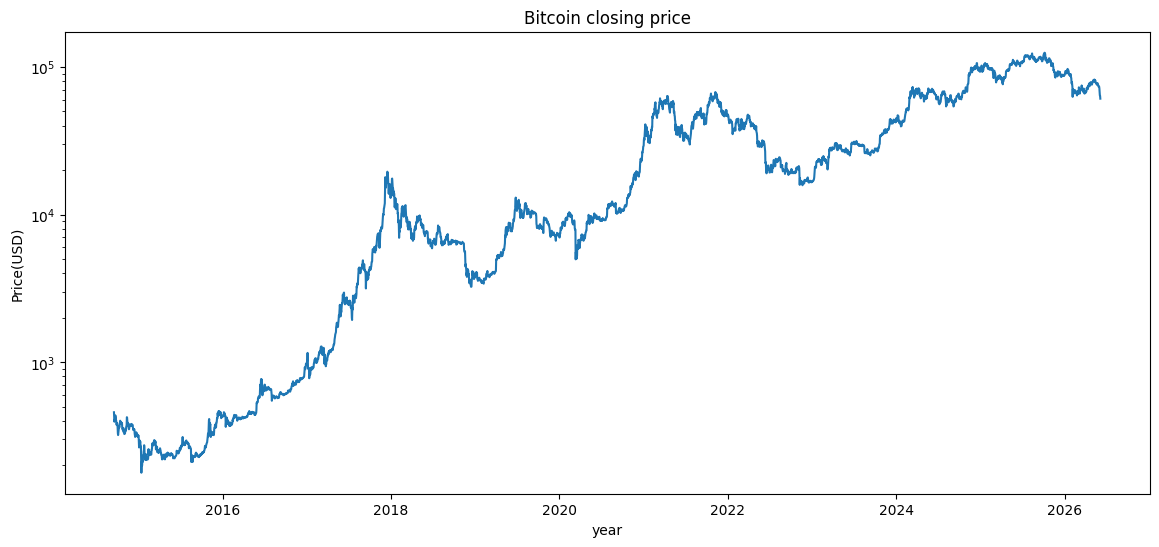

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Close"])
plt.yscale("log")
plt.xlabel("year")
plt.ylabel("Price(USD)")
plt.title("Bitcoin closing price")
save_plot("price")
plt.show()

### Findings

- Bitcoin exhibited exponential long-term growth.
- Multiple bull and bear market cycles are visible.
- Significant drawdowns occurred during major market events.

## Daily Return Analysis

Objective:
Measure day-to-day percentage changes in Bitcoin prices.

In [11]:
df["Daily_return"]=df["Close"].pct_change()
print(df[["Date","Close","Daily_return"]].head(10))
df["Daily_return"].describe()

        Date       Close  Daily_return
0 2014-09-17  457.334015           NaN
1 2014-09-18  424.440002     -0.071926
2 2014-09-19  394.795990     -0.069843
3 2014-09-20  408.903992      0.035735
4 2014-09-21  398.821014     -0.024659
5 2014-09-22  402.152008      0.008352
6 2014-09-23  435.790985      0.083647
7 2014-09-24  423.204987     -0.028881
8 2014-09-25  411.574005     -0.027483
9 2014-09-26  404.424988     -0.017370


count    4279.000000
mean        0.001758
std         0.034916
min        -0.371695
25%        -0.012617
50%         0.001073
75%         0.015884
max         0.252472
Name: Daily_return, dtype: float64

In [12]:
best_day=df.loc[df["Daily_return"].idxmax()]
worst_day=df.loc[df["Daily_return"].idxmin()]
print("best_day")
print(best_day[["Date","Close","Daily_return"]])
print()
print("worst_day")
print(worst_day[["Date","Close","Daily_return"]])

best_day
Date            2017-12-07 00:00:00
Close                  17899.699219
Daily_return               0.252472
Name: 1177, dtype: object

worst_day
Date            2020-03-12 00:00:00
Close                   4970.788086
Daily_return              -0.371695
Name: 2003, dtype: object


### Findings

Largest Gain:
- 2017-12-07
- +25.25%

Largest Loss:
- 2020-03-12
- -37.17%

The COVID-19 crash produced the largest single-day decline in the dataset.

## Return Distribution

Objective:
Understand the distribution of daily returns.

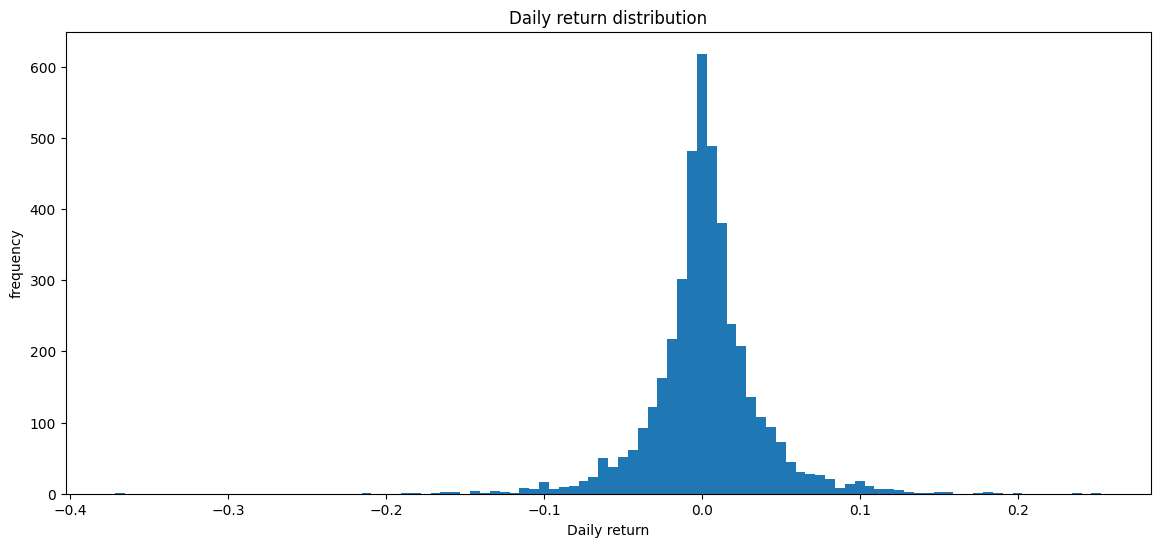

In [13]:
plt.figure(figsize=(14,6))
plt.hist(df["Daily_return"].dropna(),bins=100)
plt.title("Daily return distribution")
plt.xlabel("Daily return")
plt.ylabel("frequency")
save_plot("Daily_return_destribution")
plt.show()

### Findings

- Most returns cluster around 0%.
- Extreme gains and losses are rare.
- Distribution exhibits heavy tails.